# NB01 Text Representation (Axis1)

## Member1 (Rui): TF-IDF Unigrams & Bigrams (Week01)
 Input: nlp_abstracts_cleaned.csv

 Output: tfidf_unigram_matrix.pkl, tfidf_bigram_matrix.pkl

**Note**: 
The current version (Week01) is a sample based on **10% of the data**. It aims to quickly generate a sample matrix to resolve the potential problems for Member 3, 4, and 5. 
 Full data operation will be conducted in Week 03.

In [45]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
df_nlp = pd.read_csv("../data/nlp_abstracts_clean.csv")

In [47]:
print(f"TOTAL: {len(df_nlp)}")
print(df_nlp["period"].value_counts().sort_index())

TOTAL: 32221
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


### Sample 10%

In [48]:
# sample 10% of the data
df = df_nlp.sample(frac=0.1, random_state=42).copy()
print(f"TOTAL: {len(df_nlp)}")
print(f"SAMPLE 10%: {len(df)}") 

TOTAL: 32221
SAMPLE 10%: 3222


In [49]:
# text cleaning
def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [50]:
df["abstract_clean"] = df["abstract"].apply(clean_abstract)
df = df[df["abstract_clean"].str.len() > 20].copy()
print(f"the Number of 10% Papers after Cleaning: {len(df)}")

the Number of 10% Papers after Cleaning: 3222


### Fitting TF-IDF on 10% sample

In [51]:
# sublinear_tf=True  --- use log to take word frequency, compress the weight of high-frequency words
# min_df=2 --- at least appears in 2 papers
# max_df=0.85 ---remove words that appear in more than 85% of the papers
# max_features = 10000 --- prevent filtering too many useful words on 10% of the samples

vectorizer_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.85,
    max_features=10000,
    stop_words="english",
    sublinear_tf=True,
)

vectorizer_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=2,
    max_df=0.85,
    max_features=10000,
    stop_words="english",
    sublinear_tf=True,
)

In [52]:
uni_matrix = vectorizer_uni.fit_transform(df["abstract_clean"])
bi_matrix = vectorizer_bi.fit_transform(df["abstract_clean"])

print(f"the shape of Unigram: {uni_matrix.shape}")
print(f"the shape of Bigram: {bi_matrix.shape}")

the shape of Unigram: (3222, 7993)
the shape of Bigram: (3222, 10000)


In [53]:
# Save for later use
with open("../outputs/tfidf_unigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     uni_matrix,
        "vectorizer": vectorizer_uni,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

with open("../outputs/tfidf_bigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     bi_matrix,
        "vectorizer": vectorizer_bi,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

### TOP N keywords on 10% sample

In [54]:
# Top-N by period
def top_terms_per_period(matrix, vectorizer, df, period_col="period", top_n=20):
    """
    dict: {period: [(term, score), ...]}
    method: Sum the TF-IDF scores of all papers in each period and take the top_n.
    """
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df[period_col].unique())
    results = {}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        top_idx = summed.argsort()[::-1][:top_n]
        results[period] = [(feat[i], round(summed[i], 2)) for i in top_idx]
    return results


print("\nUnigram Top 20 per period ")
uni_top = top_terms_per_period(uni_matrix, vectorizer_uni, df, top_n=20)
for period, terms in uni_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")

print("\nBigram Top 20 per period ")
bi_top = top_terms_per_period(bi_matrix, vectorizer_bi, df, top_n=20)
for period, terms in bi_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")



Unigram Top 20 per period 
1991-1995: grammars, grammar, ambiguity, lexical, theory, based, parsing, language, algorithm, presents, used, paper, corpus, present, formalism, disambiguation, implemented, linguistic, results, model
1996-2000: algorithm, paper, words, constraints, speech, based, language, dialogue, word, set, use, problem, information, method, grammars, used, linguistic, pronouns, grammar, described
2001-2005: language, algorithm, proposed, parsing, used, paper, annotation, corpus, corpora, application, analysis, natural, likelihood, algorithms, maximum, programming, present, automata, using, applications
2006-2010: automata, words, rules, resources, paper, introduced, used, documents, lexicon, language, annotation, written, parallel, logical, case, algorithm, russian, based, tool, linguistic
2011-2015: language, based, words, paper, word, approach, using, text, used, translation, model, results, information, features, different, languages, learning, use, models, data
201

### Vocabulary Comparison on 10% sample

In [55]:
# Vocabulary Comparison Across Periods (Rise VS. Disappearance)
def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words  = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
print(f"\nUnigram emerging words: {sorted(uni_emerged)}")
print(f"Unigram disappearing words: {sorted(uni_disappeared)}")

bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)
print(f"\nBigram emerging words: {sorted(bi_emerged)}")
print(f"Bigram disappearing words: {sorted(bi_disappeared)}")




Unigram emerging words: ['approach', 'data', 'different', 'features', 'languages', 'learning', 'models', 'neural', 'performance', 'propose', 'state', 'task', 'tasks', 'text', 'training', 'translation']
Unigram disappearing words: ['algorithm', 'algorithms', 'ambiguity', 'analysis', 'annotation', 'application', 'applications', 'automata', 'constraints', 'corpora', 'corpus', 'described', 'dialogue', 'disambiguation', 'formalism', 'grammar', 'grammars', 'implemented', 'lexical', 'likelihood', 'linguistic', 'maximum', 'method', 'natural', 'parsing', 'present', 'presents', 'problem', 'programming', 'pronouns', 'proposed', 'set', 'speech', 'theory']

Bigram emerging words: ['arabic language', 'based approach', 'deep learning', 'end end', 'et al', 'experimental results', 'information retrieval', 'language model', 'language models', 'large scale', 'literary texts', 'low dimensional', 'machine translation', 'neural network', 'neural networks', 'paper propose', 'pre trained', 'propose novel', '

### Representative vocabulary changes by period (10% sample)

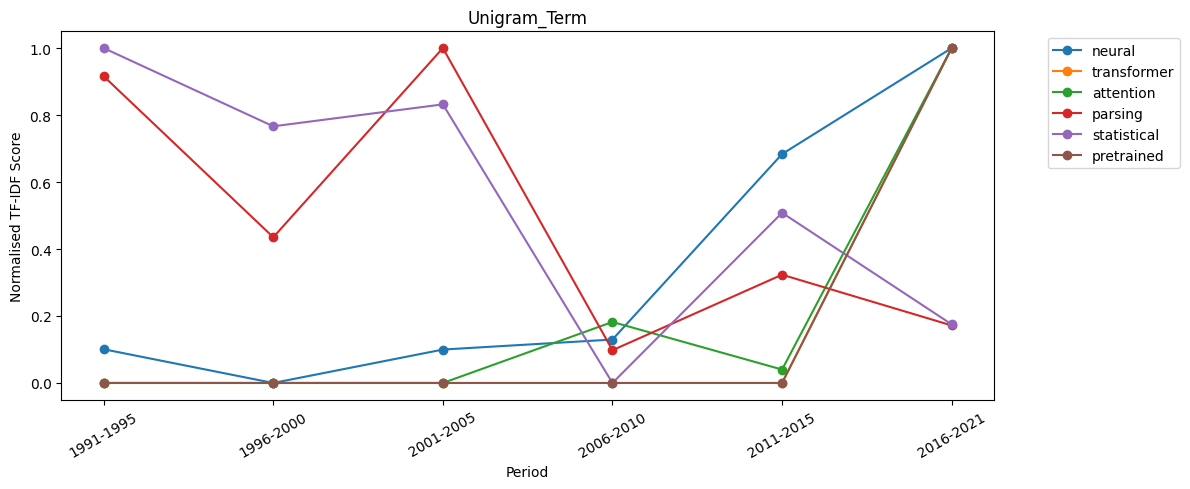

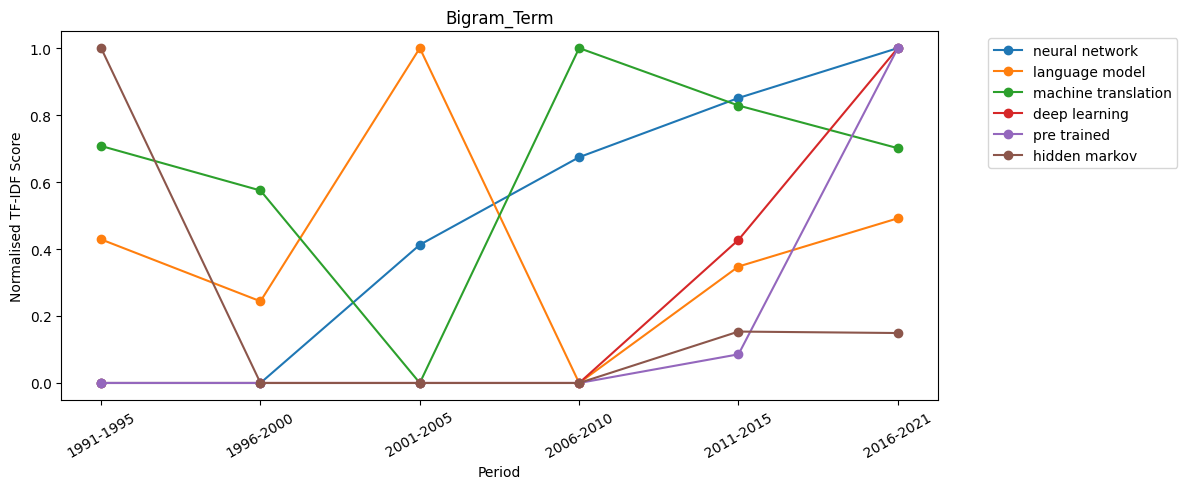

In [56]:
def plot_term_trends(matrix, vectorizer, df, terms, period_col="period", title=""):
    feat  = list(vectorizer.get_feature_names_out())
    periods = sorted(df[period_col].unique())
    valid = [t for t in terms if t in feat]
    if not valid:
        print("None specified terms")
        return

    scores = {t: [] for t in valid}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid:
            scores[t].append(summed[feat.index(t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

unigram_track = ["neural", "transformer", "attention", "parsing", "statistical", "pretrained"]
plot_term_trends(uni_matrix, vectorizer_uni, df, unigram_track, title="Unigram_Term")

bigram_track = ["neural network", "language model", "machine translation",
                "deep learning", "pre trained", "hidden markov"]
plot_term_trends(bi_matrix, vectorizer_bi, df, bigram_track, title="Bigram_Term")



According to Unigram plot: 

 - "Statistical" was the absolute king in 1991-1995, then declined; parsing (syntactic analysis, a core task of early NLP) peaked in 2001-2005 and then began to decline. 
 - "Neural", "Attention", "Transformer" (the terms of the deep learning era) were all zeros until 2010, and then exploded after 2015

According to Bigram plot: 
 - "hidden markov" (the early leader in speech and sequence annotation) was at its peak in the 1990s and has since gradually been phased out. 
 - "Machine translation" had a clear peak around 2006-2010, when statistical machine translation SMT was at its best
 - "Neural network" and "Deep learning" have been leading in the last decade.

## Member 2 (Dekai): SBERT Embeddings & Topic Model
Output: period_labels.pkl,sbert_matrix.pkl,lda_matrix.pkl

In [57]:
# SBERT: encode each abastract into a dense semantic vector.
from sentence_transformers import SentenceTransformer

#gensim tools for topic modelling.
from gensim import corpora
from gensim.models import LdaModel

#Cosine similarity for period-level semantic comparison.
from sklearn.metrics.pairwise import cosine_similarity

### Saving period labels
Saving index, period, and era as a stable reference so that later analyses(cosine distance, PCA, report tables) could stay aligned.

In [83]:
with open("../outputs/period_labels.pkl", "wb") as f:
    pickle.dump({
        "index": df.index,
        "period": df["period"].values,
        "era": df["era"].values,
    }, f)

print("Saved: ../..outputs/period_labels.pkl")

Saved: ../..outputs/period_labels.pkl


### SBERT Embeddings
This section encodes each abstract into a dense semantic vector using a SentenceTransformer model.
The goal is to capture semantic drift across time periods, beyond surface-level vocabulary change.  

#### Peparing data for SBERT
Method(clean_abstract) was designed for TF-IDF. It removes punctuation, numbers, and formatting aggressively. SBERT usually works better with more natural sentence-like input. So it is better to keep the text closer to natural language.

In [84]:
#Make a copy.
df_sbert = df.copy()
#Clean the data.
df_sbert["abstract_sbert"] = df_sbert["abstract"].fillna("").astype(str).str.strip()
#Filter out extremely short texts.
df_sbert = df_sbert[df_sbert["abstract_sbert"].str.len() > 20].copy()

print("Number of paper for SBERT:", len(df_sbert))
df_sbert[["abstract_sbert", "period"]].head()

Number of paper for SBERT: 3222


,abstract_sbert,period
11582,One of the key requirements to facilitate the ...,2016-2021
20725,We demonstrate the complementary natures of ne...,2016-2021
4421,End-to-end design of dialogue systems has rece...,2016-2021
8194,This paper illustrates the interface of the to...,2016-2021
29747,We introduce Language-Informed Latent Actions ...,2016-2021


#### Loading SBERT model

In [85]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("SBERT model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT model loaded


#### Encoding abstracts with SBERT
The method of model(encode()) could transforms each abstract into an embedding vector.

In [86]:
sbert_matrix = sbert_model.encode(
    df_sbert["abstract_sbert"].tolist(),
    #process 500 abstracts at a time
    batch_size=500,
    #display progress while encoding.
    show_progress_bar=True,
    #return a NumPy array.
    convert_to_numpy=True
)

print("SBERT matrix shape:", sbert_matrix.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

SBERT matrix shape: (3222, 384)


In [87]:
# Save SBERT matrix
with open("../outputs/sbert_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": sbert_matrix,
        "model_name": "all-MiniLM-L6-v2",
        "index": df_sbert.index,
        "period": df_sbert["period"].values,
        "era": df_sbert["era"].values,
    }, f)

print("Saved: outputs/sbert_matrix.pkl")

Saved: outputs/sbert_matrix.pkl


#### Computing semantic similarity by period

In [88]:
# Get all unique periods and sort them.
periods_sbert = sorted(df_sbert["period"].unique())
# Compute one centroid (average embedding) per period.
period_centroids = []

for period in periods_sbert:
    #Create a boolean mask
    bool_mask = (df_sbert["period"] == period).values
    # Average all document embeddings in this period.
    centroid = sbert_matrix[bool_mask].mean(axis=0)
    period_centroids.append(centroid)

# Stack all centroids into one matrix
period_centroids = np.vstack(period_centroids)

print("Period centroid matrix shape:", period_centroids.shape)

# Compute cosine similarity between period centroids.
semantic_similarity = cosine_similarity(period_centroids)

# Convert to DataFrame.
similarity_df = pd.DataFrame(
    semantic_similarity,
    index=periods_sbert,
    columns=periods_sbert
)

print("Semantic similarity matrix:")
similarity_df
    

Period centroid matrix shape: (6, 384)
Semantic similarity matrix:


,1991-1995,1996-2000,2001-2005,2006-2010,2011-2015,2016-2021
1991-1995,1.000000,0.947625,0.900631,0.870634,0.846634,0.728641
1996-2000,0.947625,1.000000,0.945332,0.849428,0.915274,0.823000
2001-2005,0.900631,0.945332,1.000000,0.866199,0.922961,0.818959
2006-2010,0.870634,0.849428,0.866199,1.000000,0.836072,0.671634
2011-2015,0.846634,0.915274,0.922961,0.836072,1.000000,0.929425
2016-2021,0.728641,0.823000,0.818959,0.671634,0.929425,1.000000


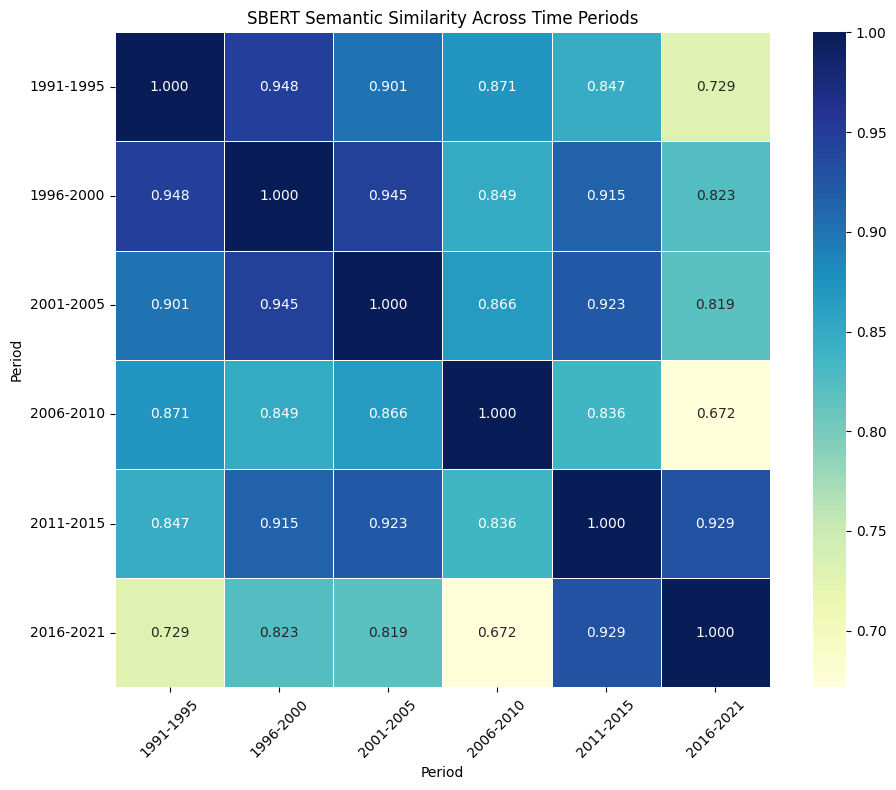

In [89]:
# Draw the heatmap.

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Similarity Across Time Periods")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This figure suggests that:

- Adjacent periods are generally more similar.

For example, 1991–1995 is highly similar to 1996–2000, and 1996–2000 is highly similar to 2001–2005.
This indicates that NLP evolved gradually rather than abruptly.
- Longer time gaps usually correspond to lower similarity.

For instance, the similarity between 1991–1995 and 2016–2021 is only 0.729, which is much lower than neighbouring periods.
This suggests that early NLP and recent NLP differ substantially in focus and scientific language.
- 2011–2015 and 2016–2021 remain relatively close.

Their similarity is 0.929, indicating strong continuity between the two most recent periods.
So the latest phase is not a complete break, but rather an extension of the previous one.

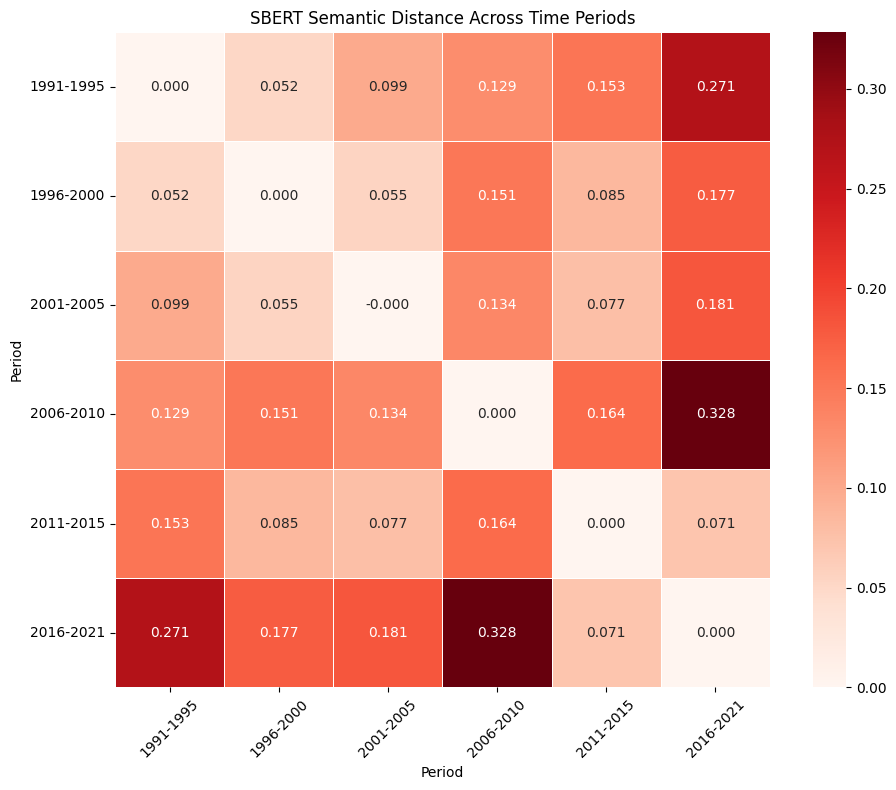

In [90]:
# draw the distance heatmap
distance_df = 1 - similarity_df

plt.figure(figsize=(10, 8))

sns.heatmap(
    distance_df,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Distance Across Time Periods")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This figure shows that:

- The largest distance is between 2006–2010 and 2016–2021.

Their distance is 0.328, the highest value in the matrix.
This suggests a particularly strong semantic shift between these two periods.
- The distance between 1991–1995 and 2016–2021 is also large (0.271).

This indicates that, over the long term, NLP has become clearly different from its early form.
- Adjacent periods tend to have smaller distances.

For example, the distance between 1991–1995 and 1996–2000 is only 0.052.
Again, this supports the idea that:
short-term change is limited, but long-term change accumulates and becomes substantial.

### LDA Topic Model
This section models each abstract as a mixture of latent topics.  
The goal is to examine how topic proportions change across historical periods.  

#### Preparing data for LDA

In [91]:
# Make a copy
df_lda = df.copy()

print("Initial number of papers for LDA:", len(df_lda))

Initial number of papers for LDA: 3222


In [92]:
# Cleaning function for LDA
# Clean one abstract and return a token list for LDA.
def clean_for_lda(text):
    if not isinstance(text, str):
        return []
    
    # Lowercase all text.
    text = text.lower()
    
    # Keep only letters and spaces.
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Replace multiple spaces with one space, then strip edges.
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize by spaces.
    tokens = text.split()
    
    # Remove very short tokens.
    tokens = [t for t in tokens if len(t) > 2]
    
    return tokens

In [93]:
# Tokenize abstracts for LDA
df_lda["abstract_lda_tokens"] = df_lda["abstract"].apply(clean_for_lda)

# Remove documents with too few tokens.
df_lda = df_lda[df_lda["abstract_lda_tokens"].map(len) > 5].copy()

print("Number of papers for LDA after filtering:", len(df_lda))
df_lda[["abstract_lda_tokens", "period"]].head()

Number of papers for LDA after filtering: 3221


,abstract_lda_tokens,period
11582,"[one, the, key, requirements, facilitate, the,...",2016-2021
20725,"[demonstrate, the, complementary, natures, neu...",2016-2021
4421,"[end, end, design, dialogue, systems, has, rec...",2016-2021
8194,"[this, paper, illustrates, the, interface, the...",2016-2021
29747,"[introduce, language, informed, latent, action...",2016-2021


#### Building dictionary and corpus

In [94]:
# Create a dictionary from all tokenized abstracts.
lda_dictionary = corpora.Dictionary(df_lda["abstract_lda_tokens"])

# Remove extreme words:
# - no_below=5: keep words appearing in at least 5 documents
# - no_above=0.85: remove words appearing in more than 85% of documents
lda_dictionary.filter_extremes(no_below=5, no_above=0.85)

# Convert each document into bag-of-words format.
lda_corpus = [lda_dictionary.doc2bow(tokens) for tokens in df_lda["abstract_lda_tokens"]]

print("Dictionary size", len(lda_dictionary))
print("Corpus size", len(lda_corpus))

Dictionary size 4745
Corpus size 3221


#### Training LDA model
LDA represents each document as a mixture of latent topics.
Each topic is a distribution over words.

In [95]:
num_topics = 10

lda_model = LdaModel(
    corpus=lda_corpus,          
    id2word=lda_dictionary,     
    num_topics=num_topics,  
    # fixed random seed
    random_state=42,
    # number of passes over the corpus
    passes=10, 
    # batch size
    chunksize=1000, 
    # automatically learn alpha
    alpha="auto",               
    per_word_topics=False
)

print("LDA model trained")

LDA model trained


In [96]:
# Check topics
for topic_id in range(num_topics):
    print(f"Topic {topic_id}:")
    print(lda_model.print_topic(topic_id, topn=10))

Topic 0:
0.026*"for" + 0.017*"this" + 0.014*"sentiment" + 0.013*"analysis" + 0.013*"are" + 0.012*"text" + 0.012*"that" + 0.011*"with" + 0.011*"based" + 0.009*"which"
Topic 1:
0.020*"that" + 0.016*"model" + 0.013*"for" + 0.013*"our" + 0.012*"with" + 0.011*"this" + 0.010*"models" + 0.008*"which" + 0.008*"propose" + 0.008*"based"
Topic 2:
0.020*"question" + 0.017*"for" + 0.014*"from" + 0.014*"knowledge" + 0.014*"questions" + 0.013*"dataset" + 0.012*"this" + 0.012*"that" + 0.012*"user" + 0.011*"dialogue"
Topic 3:
0.025*"that" + 0.024*"language" + 0.019*"for" + 0.018*"are" + 0.017*"this" + 0.009*"can" + 0.009*"these" + 0.009*"natural" + 0.008*"with" + 0.007*"have"
Topic 4:
0.073*"semantic" + 0.065*"syntactic" + 0.048*"syntax" + 0.034*"resolution" + 0.033*"parser" + 0.033*"sentences" + 0.032*"rhetorical" + 0.027*"coreference" + 0.025*"semantics" + 0.017*"expressions"
Topic 5:
0.027*"word" + 0.018*"knowledge" + 0.017*"that" + 0.016*"embeddings" + 0.015*"domain" + 0.012*"embedding" + 0.011*"ar

#### Building dense LDA matrix

In [97]:
# Create an empty matrix
lda_matrix = np.zeros((len(lda_corpus), num_topics))

for i, bow in enumerate(lda_corpus):
    # Get topic probabilities for one document.
    doc_topics = lda_model.get_document_topics(bow, minimum_probability=0)
    
    # Fill the dense matrix.
    for topic_id, prob in doc_topics:
        lda_matrix[i, topic_id] = prob

print("LDA matrix shape:", lda_matrix.shape)

LDA matrix shape: (3221, 10)


In [98]:
#save LDA matrix
with open("../outputs/lda_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": lda_matrix,
        "num_topics": num_topics,
        "dictionary": lda_dictionary,
        "index": df_lda.index,
        "period": df_lda["period"].values,
        "era": df_lda["era"].values,
    }, f)

print("Saved: ../outputs/lda_matrix.pkl")

Saved: ../outputs/lda_matrix.pkl


#### Computing topic proportions per period

In [99]:
# Get sorted period labels.
periods_lda = sorted(df_lda["period"].unique())

# Store the average topic distribution for each period.
topic_by_period = []

for period in periods_lda:
    bool_mask = (df_lda["period"] == period).values
    
    topic_mean = lda_matrix[bool_mask].mean(axis=0)
    topic_by_period.append(topic_mean)

# Convert to a 2D array.
topic_by_period = np.vstack(topic_by_period)

# Convert to DataFrame.
topic_period_df = pd.DataFrame(
    topic_by_period,
    index=periods_lda,
    columns=[f"Topic_{i}" for i in range(num_topics)]
)

print("Topic proportions per period:")
topic_period_df

Topic proportions per period:


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
1991-1995,0.288145,0.196891,0.038079,0.254541,0.020835,0.036281,0.005450,0.017674,0.116532,0.025572
1996-2000,0.306498,0.199656,0.042572,0.198199,0.011762,0.076376,0.004499,0.021179,0.100713,0.038548
2001-2005,0.240795,0.263012,0.028438,0.172707,0.012196,0.060165,0.008950,0.019928,0.150956,0.042852
2006-2010,0.228366,0.183331,0.040419,0.349940,0.022071,0.028650,0.016670,0.010662,0.096280,0.023609
2011-2015,0.176662,0.269709,0.035094,0.214727,0.011664,0.096859,0.027246,0.026536,0.102287,0.039215
2016-2021,0.088849,0.371970,0.076261,0.095190,0.006350,0.078901,0.039871,0.103419,0.091581,0.047608


In [100]:
#show top topics by period
for period in periods_lda:
    print(f"Top topics for {period}:")
    print(topic_period_df.loc[period].sort_values(ascending=False).head(3))

Top topics for 1991-1995:
Topic_0    0.288145
Topic_3    0.254541
Topic_1    0.196891
Name: 1991-1995, dtype: float64
Top topics for 1996-2000:
Topic_0    0.306498
Topic_1    0.199656
Topic_3    0.198199
Name: 1996-2000, dtype: float64
Top topics for 2001-2005:
Topic_1    0.263012
Topic_0    0.240795
Topic_3    0.172707
Name: 2001-2005, dtype: float64
Top topics for 2006-2010:
Topic_3    0.349940
Topic_0    0.228366
Topic_1    0.183331
Name: 2006-2010, dtype: float64
Top topics for 2011-2015:
Topic_1    0.269709
Topic_3    0.214727
Topic_0    0.176662
Name: 2011-2015, dtype: float64
Top topics for 2016-2021:
Topic_1    0.371970
Topic_7    0.103419
Topic_3    0.095190
Name: 2016-2021, dtype: float64


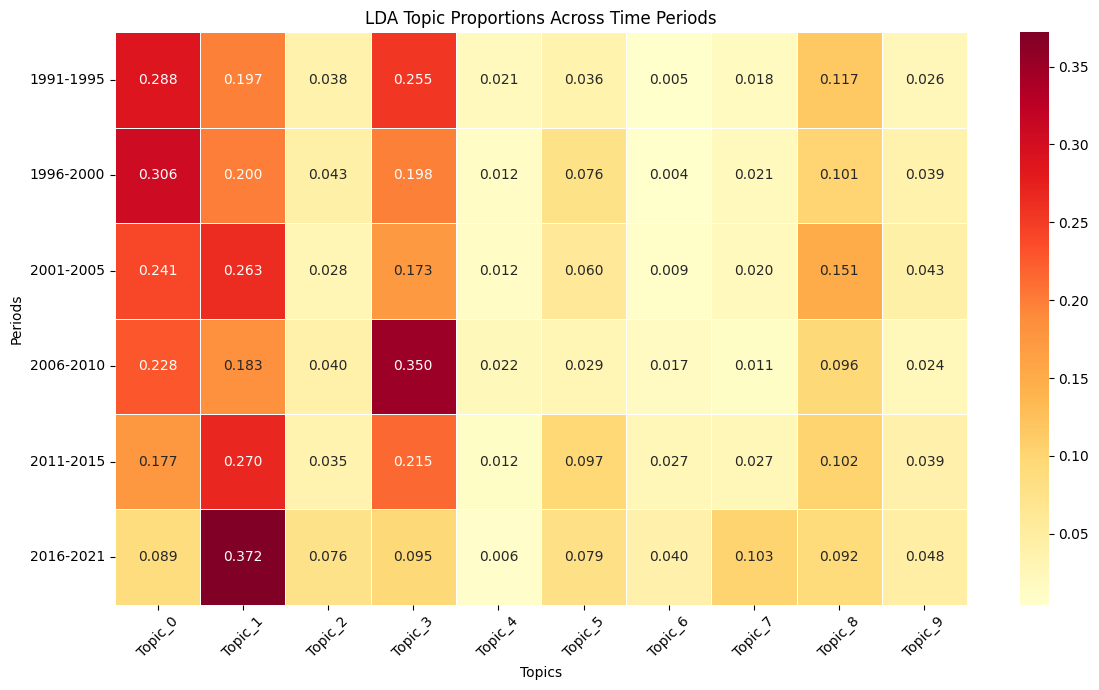

In [101]:
# Draw heatmap of topic proportions by period.
plt.figure(figsize=(12, 7))

sns.heatmap(
    topic_period_df,
    annot=True,        
    fmt=".3f",           
    cmap="YlOrRd",       
    linewidths=0.5
)

plt.title("LDA Topic Proportions Across Time Periods")
plt.xlabel("Topics")
plt.ylabel("Periods")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This figure shows how the thematic structure of NLP changes across time.

- Topic_0 is strongest in the early periods and weakens later.
It is high in 1991–1995 and 1996–2000, but drops clearly by 2016–2021.
This suggests that a theme central to early NLP becomes less dominant in modern NLP.
- Topic_1 becomes stronger in later periods, especially in 2016–2021.
In 2016–2021, Topic_1 reaches 0.372, one of the most prominent values in the heatmap.
This suggests that one theme becomes dominant in modern NLP.
- Topic_3 peaks in 2006–2010.
Its value reaches 0.350 in that period, indicating a particularly strong thematic focus in the middle stage.
- Overall, the dominant topic structure changes over time.
Early NLP is dominated more by Topic_0 and Topic_3, whereas later NLP becomes increasingly dominated by Topic_1.
This shows that NLP changes not only in wording, but also in its underlying topic composition.

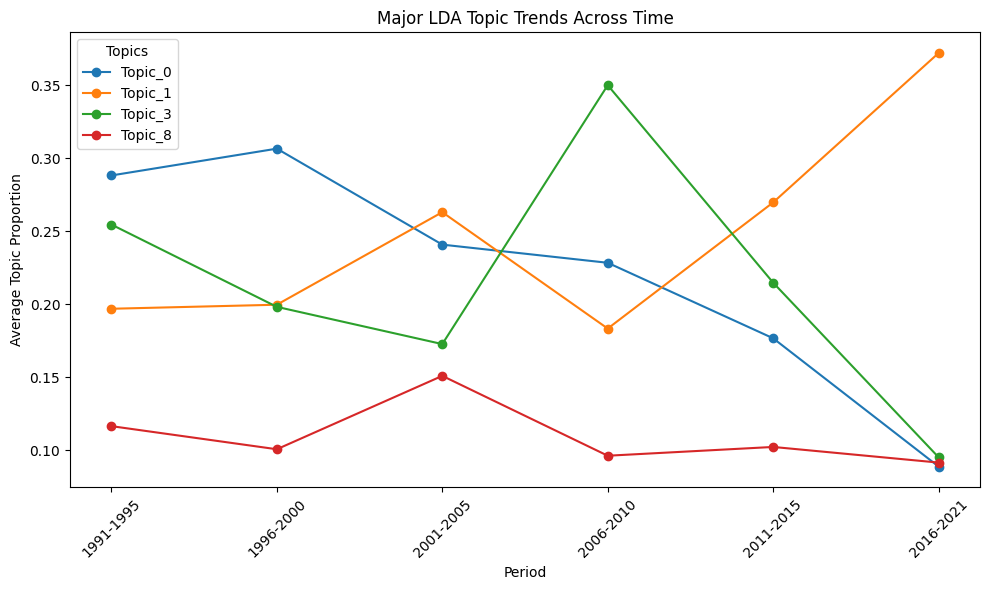

In [104]:
# Select the topics which need to track.
selected_topics = ["Topic_0", "Topic_1", "Topic_3", "Topic_8"]

plt.figure(figsize=(10, 6))

for topic in selected_topics:
    plt.plot(
        topic_period_df.index,
        topic_period_df[topic],
        marker="o",
        label=topic
    )

plt.title("Major LDA Topic Trends Across Time")
plt.xlabel("Period")
plt.ylabel("Average Topic Proportion")

plt.xticks(rotation=45)
plt.legend(title="Topics")
plt.tight_layout()
plt.show()

This figure shows that:

- Topic_0 is a classic “strong early, weaker later” topic
- Topic_1 is a “late-rising and eventually dominant” topic
- Topic_3 is a “mid-period peak” topic
- Topic_8 changes less dramatically and looks more like a secondary theme

So this figure supports a key conclusion:

the thematic structure of NLP is not fixed over time; instead, different topics dominate in different historical phases.